# 03 - Eğitim ve Değerlendirme (Geliştirilmiş)
Hiperparametre tuning, özellik seçimi, eşik kalibrasyonu, F1-Score ve EIF desteği.

In [3]:
import os, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    average_precision_score,
    f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


In [4]:
# ── AYARLAR ──────────────────────────────────────────
BASE_DIR     = r'C:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final'
MACHINE_TYPE = 'fan'
MODEL_IDS    = ['id_00', 'id_02', 'id_04', 'id_06']

# Hiperparametre arama aralıkları
N_ESTIMATORS_LIST  = [100, 150]
MAX_SAMPLES_LIST   = ['auto', 256]
CONTAMINATION_LIST = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

N_FEATURES_SELECT = 60   # Mutual Information ile seçilecek özellik sayısı
USE_EIF           = False # True yapıp pip install eif ile dene
# ─────────────────────────────────────────────────────

FEATURES_DIR = os.path.join(BASE_DIR, 'outputs', 'features', MACHINE_TYPE)
MODELS_DIR   = os.path.join(BASE_DIR, 'models', MACHINE_TYPE)
OUTPUTS_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(MODELS_DIR, exist_ok=True)
print('Ayarlar hazır ✓')

Ayarlar hazır ✓


## 1. Yardımcı Fonksiyonlar

In [5]:
def select_features(X_train, X_test, y_test, n=60):
    mi      = mutual_info_classif(X_test, y_test, random_state=42)
    top_idx = np.sort(np.argsort(mi)[::-1][:n])
    print(f'  {X_train.shape[1]} → {n} özellik seçildi (Mutual Information)')
    return X_train[:, top_idx], X_test[:, top_idx], top_idx, mi


def tune_hyperparams(X_tr, X_te, y_te, n_est_list, max_s_list, cont_list):
    best = {'auc': 0, 'params': {}}
    rows = []
    for n_est in n_est_list:
        for max_s in max_s_list:
            for cont in cont_list:
                m = IsolationForest(n_estimators=n_est, max_samples=max_s,
                                    contamination=cont, random_state=42, n_jobs=-1)
                m.fit(X_tr)
                auc = roc_auc_score(y_te, -m.score_samples(X_te))
                rows.append({'n_estimators': n_est, 'max_samples': str(max_s),
                              'contamination': cont, 'auc': round(auc, 4)})
                if auc > best['auc']:
                    best = {'auc': auc, 'params': {
                        'n_estimators': n_est, 'max_samples': max_s, 'contamination': cont
                    }}
    print(f'  En iyi AUC: {best["auc"]:.4f}  Params: {best["params"]}')
    return best['params'], pd.DataFrame(rows).sort_values('auc', ascending=False)


def find_best_threshold(scores, y_test):
    thresholds = np.percentile(scores, np.arange(1, 100, 1))
    best_f1, best_t = 0, thresholds[0]
    for t in thresholds:
        f1 = f1_score(y_test, (scores < t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  En iyi threshold: {best_t:.4f}  F1: {best_f1:.4f}')
    return best_t, best_f1


print('Fonksiyonlar hazır ✓')

Fonksiyonlar hazır ✓


## 2. Tüm Model ID'ler için Pipeline

In [6]:
summary = []

for model_id in MODEL_IDS:
    feat_dir = os.path.join(FEATURES_DIR, model_id)
    if not os.path.exists(feat_dir):
        print(f'[ATLA] {model_id}')
        continue

    print(f'\n══ {model_id} ══════════════════════════════')
    X_train = np.load(os.path.join(feat_dir, 'X_train.npy'))
    X_test  = np.load(os.path.join(feat_dir, 'X_test.npy'))
    y_test  = np.load(os.path.join(feat_dir, 'y_test.npy'))

    # 1. Özellik Seçimi
    print('[1] Özellik Seçimi:')
    X_tr_sel, X_te_sel, top_idx, mi_scores = select_features(
        X_train, X_test, y_test, N_FEATURES_SELECT
    )

    # 2. Ölçeklendirme
    print('[2] StandardScaler:')
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_sel)
    X_te_sc = scaler.transform(X_te_sel)

    # 3. Hiperparametre Tuning
    print('[3] Hiperparametre Tuning:')
    best_params, tuning_df = tune_hyperparams(
        X_tr_sc, X_te_sc, y_test,
        N_ESTIMATORS_LIST, MAX_SAMPLES_LIST, CONTAMINATION_LIST
    )

    # 4. Final Model
    print('[4] Final Model:')
    model = IsolationForest(**best_params, random_state=42, n_jobs=-1)
    model.fit(X_tr_sc)
    scores = model.score_samples(X_te_sc)

    # 5. Eşik Kalibrasyonu
    print('[5] Eşik Kalibrasyonu:')
    best_thresh, _ = find_best_threshold(scores, y_test)
    pred_binary = (scores < best_thresh).astype(int)

    # 6. Metrikler
    auc  = roc_auc_score(y_test, -scores)
    ap   = average_precision_score(y_test, -scores)
    prec = precision_score(y_test, pred_binary, zero_division=0)
    rec  = recall_score(y_test, pred_binary, zero_division=0)
    f1   = f1_score(y_test, pred_binary, zero_division=0)

    print(f'\nAUC-ROC   : {auc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}  ← Anomali yakalama oranı')
    print(f'F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_test, pred_binary, target_names=['Normal','Anomalous']))

    # Kaydet
    save_dir = os.path.join(MODELS_DIR, model_id)
    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(save_dir, 'model.pkl'),  'wb') as f: pickle.dump(model, f)
    with open(os.path.join(save_dir, 'scaler.pkl'), 'wb') as f: pickle.dump(scaler, f)
    np.save(os.path.join(save_dir, 'top_features.npy'), top_idx)
    with open(os.path.join(save_dir, 'results.json'), 'w') as f:
        json.dump({'model_id': model_id, 'best_params': {k: str(v) for k, v in best_params.items()},
                   'threshold': best_thresh, 'auc_roc': auc, 'avg_precision': ap,
                   'precision': prec, 'recall': rec, 'f1': f1,
                   'n_features': N_FEATURES_SELECT}, f, indent=2)

    summary.append({'model_id': model_id, 'auc': auc, 'ap': ap, 'precision': prec,
                    'recall': rec, 'f1': f1, 'threshold': best_thresh,
                    'scores': scores, 'y_test': y_test, 'pred_binary': pred_binary,
                    'mi_scores': mi_scores})

print('\n✓ Tüm modeller tamamlandı!')


══ id_00 ══════════════════════════════
[1] Özellik Seçimi:
  160 → 60 özellik seçildi (Mutual Information)
[2] StandardScaler:
[3] Hiperparametre Tuning:
  En iyi AUC: 0.5766  Params: {'n_estimators': 150, 'max_samples': 'auto', 'contamination': 0.01}
[4] Final Model:
[5] Eşik Kalibrasyonu:
  En iyi threshold: -0.3839  F1: 0.8079

AUC-ROC   : 0.5766
Precision : 0.6970
Recall    : 0.9607  ← Anomali yakalama oranı
F1-Score  : 0.8079

              precision    recall  f1-score   support

      Normal       0.67      0.16      0.26       203
   Anomalous       0.70      0.96      0.81       407

    accuracy                           0.70       610
   macro avg       0.69      0.56      0.53       610
weighted avg       0.69      0.70      0.63       610


══ id_02 ══════════════════════════════
[1] Özellik Seçimi:
  160 → 60 özellik seçildi (Mutual Information)
[2] StandardScaler:
[3] Hiperparametre Tuning:
  En iyi AUC: 0.7581  Params: {'n_estimators': 150, 'max_samples': 'auto', 'con

## 3. Özet Tablo

In [7]:
df_s = pd.DataFrame([{
    'Model ID':  r['model_id'],
    'AUC-ROC':   round(r['auc'],       4),
    'Precision': round(r['precision'], 4),
    'Recall':    round(r['recall'],    4),
    'F1-Score':  round(r['f1'],        4),
    'Threshold': round(r['threshold'], 4),
} for r in summary])
display(df_s)
print(f'\nOrtalama AUC   : {df_s["AUC-ROC"].mean():.4f}')
print(f'Ortalama Recall: {df_s["Recall"].mean():.4f}')
print(f'Ortalama F1    : {df_s["F1-Score"].mean():.4f}')

,Model ID,AUC-ROC,Precision,Recall,F1-Score,Threshold
0,id_00,0.5766,0.6970,0.9607,0.8079,-0.3839
1,id_02,0.7581,0.7763,0.9861,0.8687,-0.4210
2,id_04,0.7094,0.7191,0.9856,0.8315,-0.3969
3,id_06,0.9084,0.8084,0.9584,0.8771,-0.4133



Ortalama AUC   : 0.7381
Ortalama Recall: 0.9727
Ortalama F1    : 0.8463


## 4. Score Dağılımı + Threshold + ROC

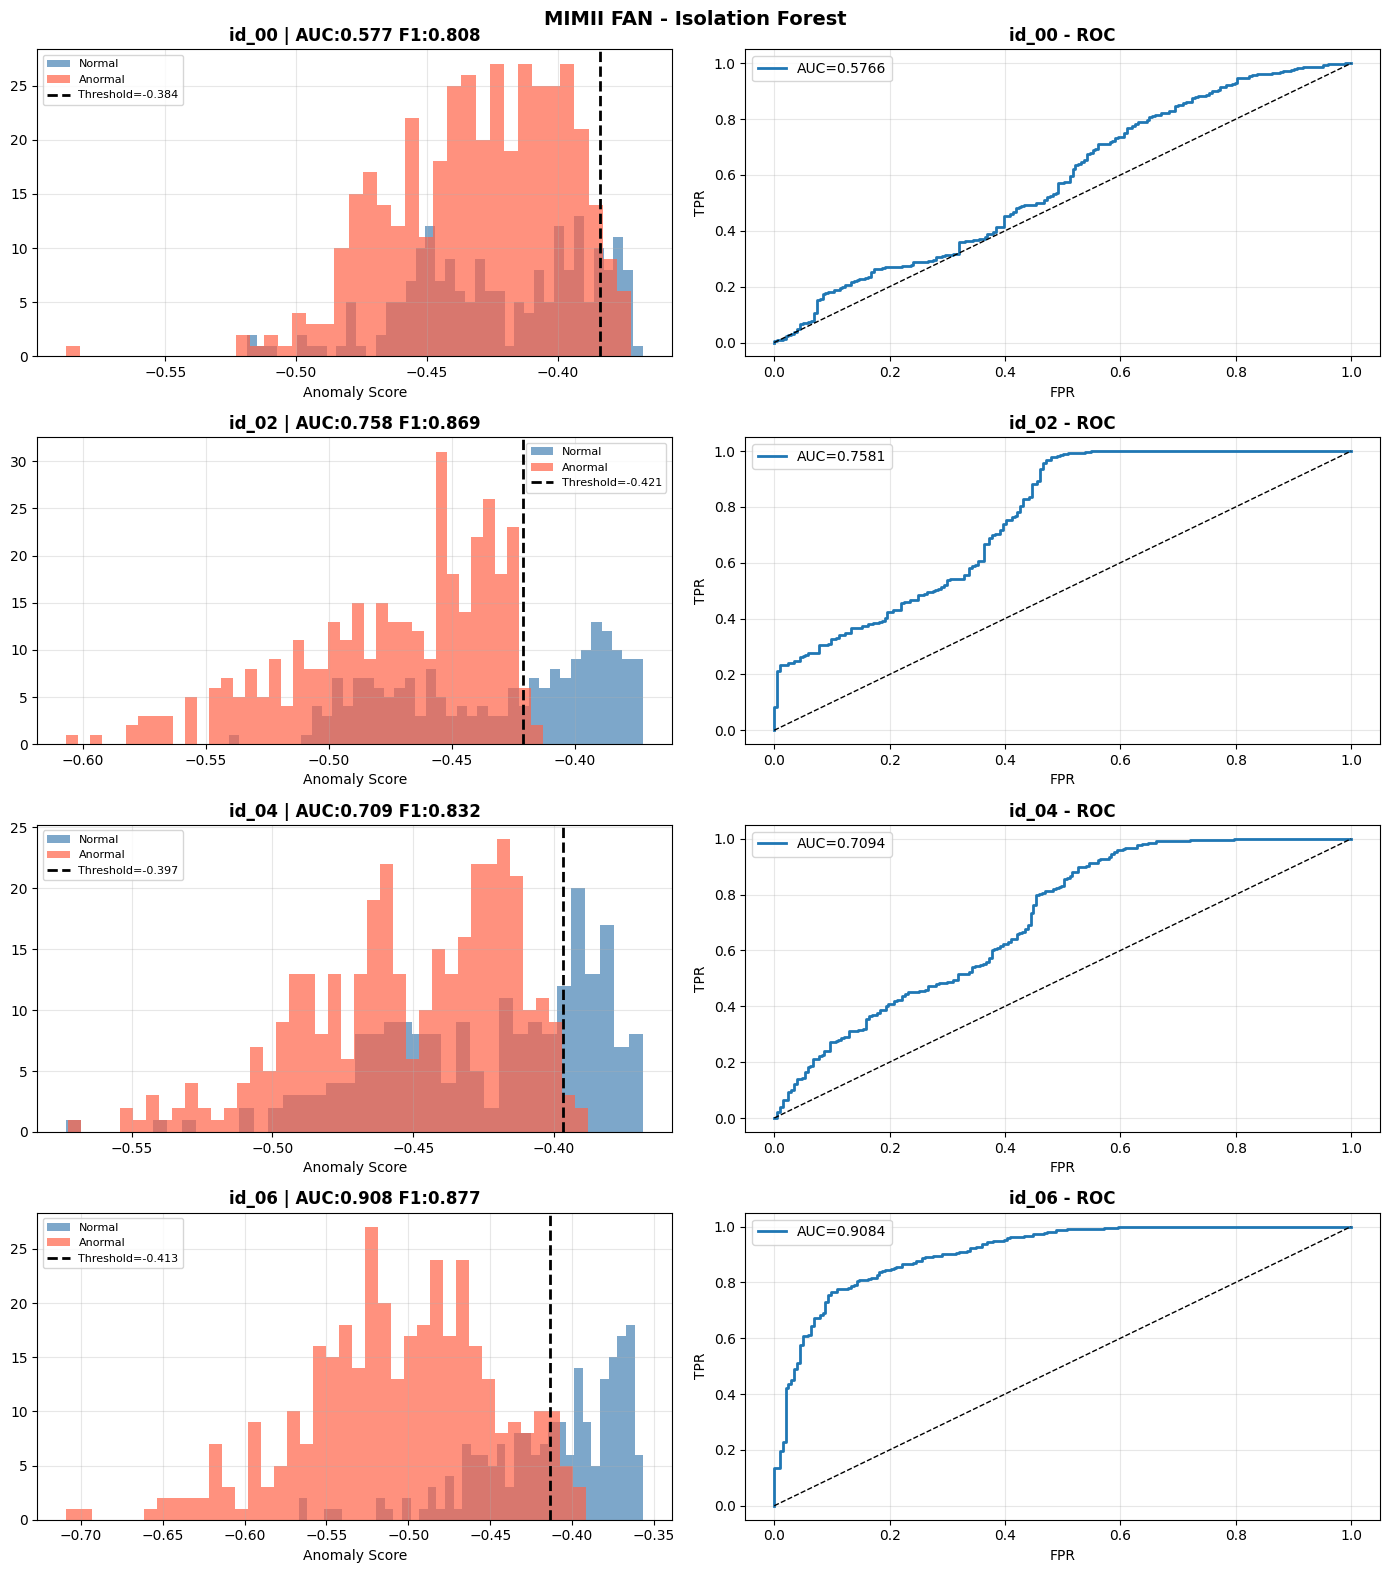

In [8]:
n = len(summary)
fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
if n == 1: axes = [axes]

for i, r in enumerate(summary):
    sc, yt = r['scores'], r['y_test']
    axes[i][0].hist(sc[yt==0], bins=40, alpha=0.7, color='steelblue', label='Normal')
    axes[i][0].hist(sc[yt==1], bins=40, alpha=0.7, color='tomato',    label='Anormal')
    axes[i][0].axvline(r['threshold'], color='black', linestyle='--', lw=2,
                        label=f'Threshold={r["threshold"]:.3f}')
    axes[i][0].set_title(f"{r['model_id']} | AUC:{r['auc']:.3f} F1:{r['f1']:.3f}",
                          fontweight='bold')
    axes[i][0].set_xlabel('Anomaly Score')
    axes[i][0].legend(fontsize=8); axes[i][0].grid(alpha=0.3)

    fpr, tpr, _ = roc_curve(yt, -sc)
    axes[i][1].plot(fpr, tpr, lw=2, label=f"AUC={r['auc']:.4f}")
    axes[i][1].plot([0,1],[0,1],'k--',lw=1)
    axes[i][1].set_title(f"{r['model_id']} - ROC", fontweight='bold')
    axes[i][1].set_xlabel('FPR'); axes[i][1].set_ylabel('TPR')
    axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

plt.suptitle(f'MIMII {MACHINE_TYPE.upper()} - Isolation Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'results_scores_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrix

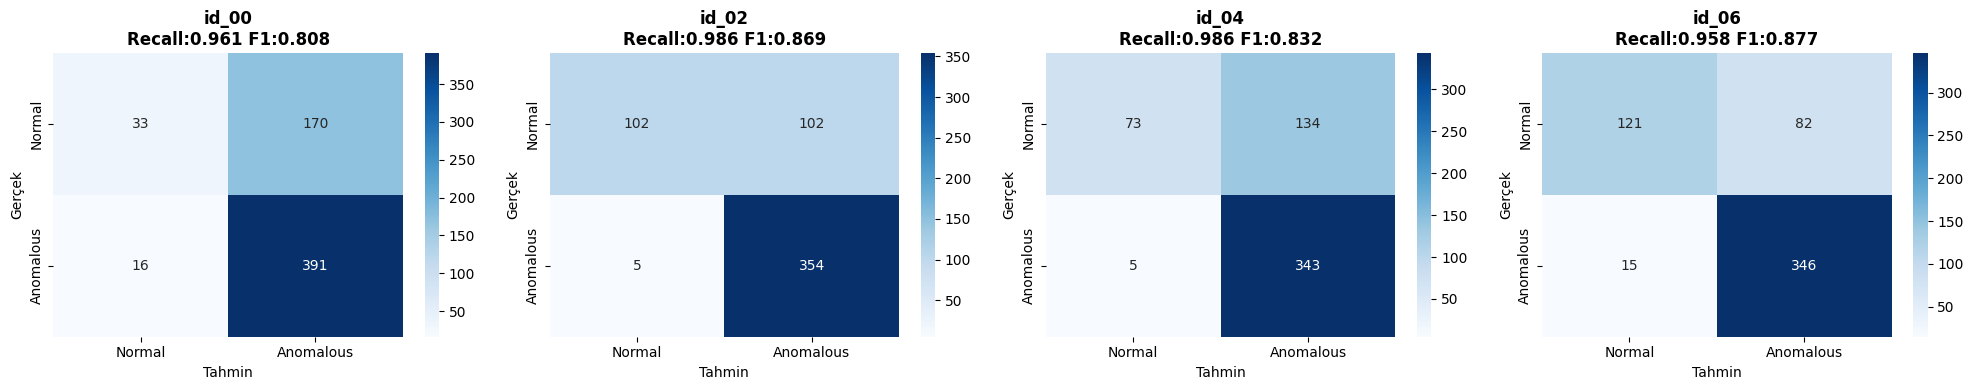

In [9]:
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]
for ax, r in zip(axes, summary):
    cm = confusion_matrix(r['y_test'], r['pred_binary'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Anomalous'],
                yticklabels=['Normal','Anomalous'], ax=ax)
    ax.set_title(f"{r['model_id']}\nRecall:{r['recall']:.3f} F1:{r['f1']:.3f}", fontweight='bold')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. En Önemli Özellikler (Mutual Information)

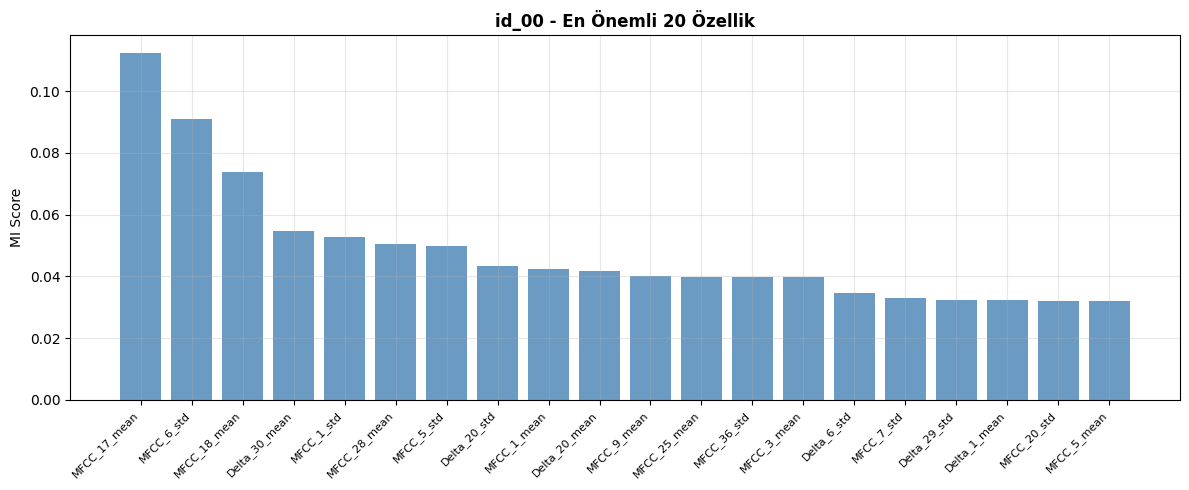

In [10]:
feature_names = (
    [f'MFCC_{i}_mean'  for i in range(40)] +
    [f'MFCC_{i}_std'   for i in range(40)] +
    [f'Delta_{i}_mean' for i in range(40)] +
    [f'Delta_{i}_std'  for i in range(40)]
)
r = summary[0]
mi = r['mi_scores']
top20 = np.argsort(mi)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), mi[top20], color='steelblue', alpha=0.8)
plt.xticks(range(20), [feature_names[i] for i in top20], rotation=45, ha='right', fontsize=8)
plt.title(f"{r['model_id']} - En Önemli 20 Özellik", fontweight='bold')
plt.ylabel('MI Score'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. (Opsiyonel) Extended Isolation Forest

In [11]:
if USE_EIF:
    try:
        import eif as iso
        for r in summary:
            feat_dir = os.path.join(FEATURES_DIR, r['model_id'])
            X_tr = np.load(os.path.join(feat_dir, 'X_train.npy'))
            X_te = np.load(os.path.join(feat_dir, 'X_test.npy'))
            yt   = np.load(os.path.join(feat_dir, 'y_test.npy'))
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
            eif  = iso.iForest(X_tr, ntrees=150, sample_size=256, ExtensionLevel=1)
            auc_eif = roc_auc_score(yt, eif.compute_paths(X_in=X_te))
            print(f"{r['model_id']}  EIF:{auc_eif:.4f}  IF:{r['auc']:.4f}")
    except ImportError:
        print('pip install eif  →  sonra USE_EIF=True yap')
else:
    print('EIF devre dışı. Denemek için: USE_EIF = True + pip install eif')

EIF devre dışı. Denemek için: USE_EIF = True + pip install eif


In [12]:
print('✓ Tamamlandı!')
print(f'Modeller  → {MODELS_DIR}')
print(f'Grafikler → {OUTPUTS_DIR}')
print('\n➡️  Gerçek zamanlı tahmin: src/realtime_detection.py')

✓ Tamamlandı!
Modeller  → C:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan
Grafikler → C:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\outputs

➡️  Gerçek zamanlı tahmin: src/realtime_detection.py
